In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
models ={
    'Oracle-1 Lite': ['../../models/Shah25b_Oracle1-lite/',],
    'Oracle-1': ['../../models/Shah25b_Oracle1/',],
    'Oracle-2 Lite': ['../../models/ELAsTiCCv2-lite/smart-river-169/',
                 '../../models/ELAsTiCCv2-lite/playful-waterfall-170/',
                 '../../models/ELAsTiCCv2-lite/happy-glade-175/',
                 '../../models/ELAsTiCCv2-lite/bright-wood-176/',
                 '../../models/ELAsTiCCv2-lite/whole-sun-177/'],
    'Oracle-2': ['../../models/ELAsTiCCv2/icy-violet-168/',
                 '../../models/ELAsTiCCv2/dazzling-river-171/',
                 '../../models/ELAsTiCCv2/rich-serenity-172/',
                 '../../models/ELAsTiCCv2/fine-violet-173/',
                 '../../models/ELAsTiCCv2/wandering-snowball-174/'],

}

colors = {
    'Oracle-2 Lite': "crimson",
    'Oracle-2': "steelblue",
    'Oracle-1 Lite': "olive",
    'Oracle-1': "gray",
}

markers = {
    'Oracle-2 Lite': 'X',
    'Oracle-2': '*',
    'Oracle-1 Lite': 'X',
    'Oracle-1': '*',
}

linestyles = {
    'Oracle-2 Lite': 'solid',
    'Oracle-2': 'solid',
    'Oracle-1 Lite': 'dashdot',
    'Oracle-1': 'dashdot',
}

In [4]:
days = 2**np.arange(0, 11)

In [11]:
def get_data(model_path, c, stat, depth, days=days):

    data = []

    for day in days:

        if model_path in models['Oracle-1 Lite'] or model_path in models['Oracle-1']:
            path = f"{model_path}/level_{depth}_csv/Trigger + {day} days.csv"
            df = pd.read_csv(path)
            df.rename(columns={df.columns[0]: "Class"}, inplace=True)
        else:
            path = f"{model_path}/reports/depth{depth}/report_trigger+{day}.csv"
            df = pd.read_csv(path)
        print(df['Class'].to_numpy())
        df_class = df[df['Class'] == c]
        value = df_class[stat].values[0]
        data.append(value)

    return np.array(data)
        

In [19]:
def get_model_stats(model_name, c, stat, depth, days=days):

    model_paths = models[model_name]
    model_data = np.zeros((len(model_paths), len(days))) 

    for i, model_path in enumerate(model_paths):
        model_data[i,:] = get_data(model_path, c, stat, depth, days)

    return np.mean(model_data, axis=0), np.std(model_data, axis=0)


In [27]:
def plot_model_stats_multi_level(c, stat):

    # make the plots next to each other for depth in [1, 2]:
    classes = ['AGN', 'CART', 'Cepheid', 'Delta Scuti', 'Dwarf Novae', 'EB', 'ILOT', 'KN',
                'M-dwarf Flare', 'PISN', 'RR Lyrae', 'SLSN', 'SNI91bg', 'SNII', 'SNIa', 'SNIax',
                'SNIb/c', 'TDE', 'uLens']
    
    fig, axs = plt.subplots(5, 4, sharex=True, sharey=True, figsize=(15, 10))

    # Remove all spacing between subplots
    plt.subplots_adjust(wspace=0, hspace=0)

    for n, c in enumerate(classes):

        i = n // 4
        j = n % 4   

        for model_name in models.keys():

            mean_f1, std_f1 = get_model_stats(model_name, c, stat, -1)

            axs[i, j].plot(days, mean_f1, label=model_name, linestyle=linestyles[model_name], color=colors[model_name], marker=markers[model_name], markeredgecolor='white', markersize=6, linewidth=0.5)
            axs[i, j].fill_between(days, mean_f1 - std_f1, mean_f1 + std_f1, color=colors[model_name], alpha=0.2)

            #axs[i, j].grid(True, which="both", linewidth=0.5, alpha=0.3)
            axs[i, j].set_xscale('log')

        if i != 4:
            axs[i, j].set_xticklabels([])
        else:

            if j == 1:
                axs[i, j].set_xlabel('Days since first detection', fontsize='large')
            axs[i, j].set_xticks(days, labels=days, rotation=60)

        if j != 0:
            pass
            #axs[i, j].set_yticklabels([])
        else:
            if i == 2:
                axs[i, j].set_ylabel('F1 Score', fontsize='large')
        axs[i, j].text(0.8, 0.06, f'{c}', transform=axs[i, j].transAxes, ha='center', fontsize='medium')


        #plt.xticks(days, labels=days)
        # plt.xlabel('Days since first detection', fontsize='xx-large' )
        # plt.ylabel(stat, fontsize='xx-large')
        # plt.title(f'Depth {depth}')

    # Get handles and labels from the last axis to use in the figure legend
    handles, labels = axs[1,1].get_legend_handles_labels()

    # Use fig.legend for centering across the whole figure
    fig = plt.gcf()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.03), ncol=len(models), fontsize='x-large')
    
    # Adjust tight_layout to leave room for the legend at the bottom
    plt.tight_layout(rect=[0, 0.02, 1, 1])

    # make a single legend for both plots at the bottom of the whole figure, not just the first plot
    #plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=len(models))
    plt.savefig(f"BTS_F1_per_class.pdf", bbox_inches='tight')
    plt.show()

['AGN' 'CART' 'Cepheid' 'Delta Scuti' 'Dwarf Novae' 'EB' 'ILOT' 'KN'
 'M-dwarf Flare' 'PISN' 'RR Lyrae' 'SLSN' 'SNI91bg' 'SNII' 'SNIa' 'SNIax'
 'SNIb/c' 'TDE' 'uLens' 'accuracy' 'macro avg' 'weighted avg']
['AGN' 'CART' 'Cepheid' 'Delta Scuti' 'Dwarf Novae' 'EB' 'ILOT' 'KN'
 'M-dwarf Flare' 'PISN' 'RR Lyrae' 'SLSN' 'SNI91bg' 'SNII' 'SNIa' 'SNIax'
 'SNIb/c' 'TDE' 'uLens' 'accuracy' 'macro avg' 'weighted avg']
['AGN' 'CART' 'Cepheid' 'Delta Scuti' 'Dwarf Novae' 'EB' 'ILOT' 'KN'
 'M-dwarf Flare' 'PISN' 'RR Lyrae' 'SLSN' 'SNI91bg' 'SNII' 'SNIa' 'SNIax'
 'SNIb/c' 'TDE' 'uLens' 'accuracy' 'macro avg' 'weighted avg']
['AGN' 'CART' 'Cepheid' 'Delta Scuti' 'Dwarf Novae' 'EB' 'ILOT' 'KN'
 'M-dwarf Flare' 'PISN' 'RR Lyrae' 'SLSN' 'SNI91bg' 'SNII' 'SNIa' 'SNIax'
 'SNIb/c' 'TDE' 'uLens' 'accuracy' 'macro avg' 'weighted avg']
['AGN' 'CART' 'Cepheid' 'Delta Scuti' 'Dwarf Novae' 'EB' 'ILOT' 'KN'
 'M-dwarf Flare' 'PISN' 'RR Lyrae' 'SLSN' 'SNI91bg' 'SNII' 'SNIa' 'SNIax'
 'SNIb/c' 'TDE' 'uLens' 'accuracy

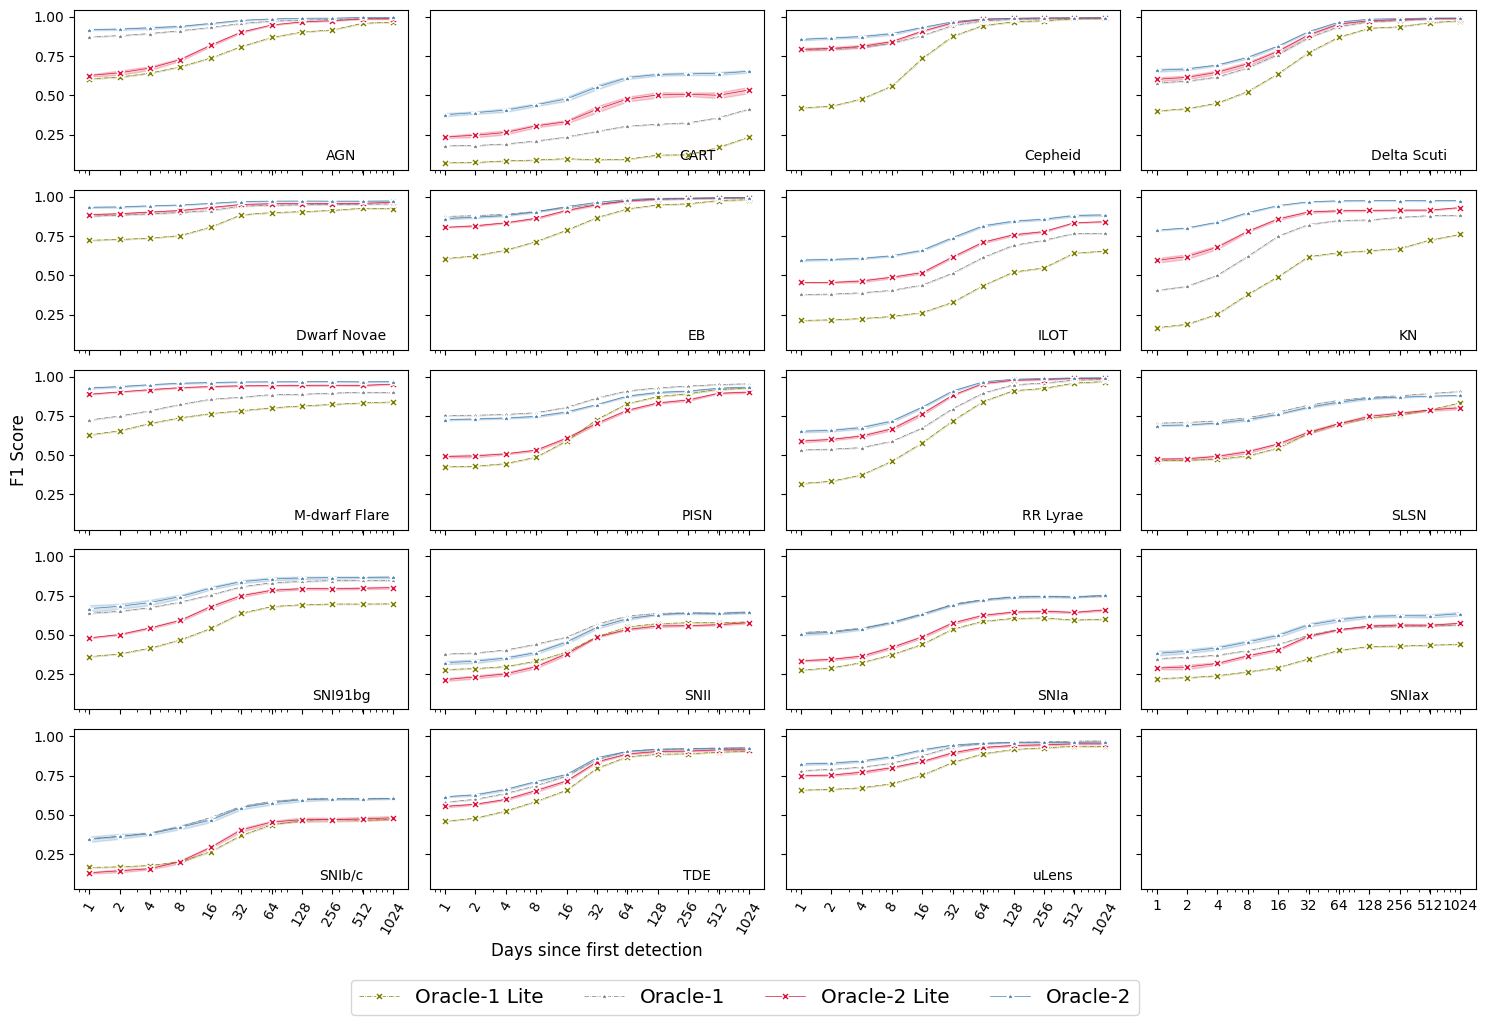

In [28]:
plot_model_stats_multi_level('macro avg', 'f1-score')